| Concept                                  | Description                                                                                                                                                  |                                                                |
| ---------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------- |
| **Boolean Indexing**                     | True/False condition ব্যবহার করে DataFrame থেকে rows filter করা। Data cleaning ও feature selection-এ বেশি ব্যবহৃত।                                           |                                                                |
| **Single condition**                     | `df[df['col'] > val]` → একটি condition অনুযায়ী filter।                                                                                                      |                                                                |
| **Multiple conditions (AND / OR / NOT)** | `&` → AND, `                                                                                                                                                 | `→ OR,`~`→ NOT. উদাহরণ:`df[(df['col1']>10) & (df['col2']==5)]` |
| **isin()**                               | `df[df['col'].isin([val1,val2])]` → multiple value match।                                                                                                    |                                                                |
| **between()**                            | `df[df['col'].between(low, high)]` → value range filter।                                                                                                     |                                                                |
| **any() / all()**                        | Column-wise বা row-wise check করতে। উদাহরণ: `df[df[['col1','col2']].any(axis=1)]`                                                                            |                                                                |
| **ML Application**                       | - Outlier removal: `df[df.salary < upper_bound]`<br>- Positive class selection: `df[df['label']==1]`<br>- Subset selection for training or balancing classes |                                                                |


In [1]:
import pandas as pd

In [2]:
df = pd.DataFrame({
  'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
  'Age' : [25,30,17,45,28],
  'Salary': [50000,80000,12000,23333,60000],
  'Dept': ['IT', 'HR', 'IT', 'IT', 'Finance']
})

df

,Name,Age,Salary,Dept
0,Alice,25,50000,IT
1,Bob,30,80000,HR
2,Charlie,17,12000,IT
3,David,45,23333,IT
4,Eve,28,60000,Finance


In [7]:
adults = df[df['Age'] >= 18]

In [8]:
adults

,Name,Age,Salary,Dept
0,Alice,25,50000,IT
1,Bob,30,80000,HR
3,David,45,23333,IT
4,Eve,28,60000,Finance


DataFrame-এর প্রতিটি row-এর জন্য condition check করে। যেগুলো True → রাখে, যেগুলো False → বাদ দেয়।

In [10]:
it_high = df[(df['Dept'] == 'IT') & (df['Salary'] >= 40000)]

it_high

,Name,Age,Salary,Dept
0,Alice,25,50000,IT


In [15]:
it_high = df[(df['Dept'] == 'IT') | (df['Salary'] > 60000)]

it_high

,Name,Age,Salary,Dept
0,Alice,25,50000,IT
1,Bob,30,80000,HR
2,Charlie,17,12000,IT
3,David,45,23333,IT


In [17]:
not_it = df[~(df['Dept'] == 'IT')]

not_it

,Name,Age,Salary,Dept
1,Bob,30,80000,HR
4,Eve,28,60000,Finance


.isin() একটি list নেয় এবং যে row-গুলো list-এর যেকোনো value match করে সেগুলো রাখে। এটা multiple == এর বিকল্প।

এটা না লিখে:

df[(df['Dept'] == 'IT') | (df['Dept'] == 'HR')]

এভাবে লিখো:

it_hr = df[df['Dept'].isin(['IT', 'HR'])]

In [18]:
it_hr = df[df['Dept'].isin(['IT','HR'])]

it_hr

,Name,Age,Salary,Dept
0,Alice,25,50000,IT
1,Bob,30,80000,HR
2,Charlie,17,12000,IT
3,David,45,23333,IT


In [19]:
mid_salary = df[df['Salary'].between(50000,70000)]

mid_salary

,Name,Age,Salary,Dept
0,Alice,25,50000,IT
4,Eve,28,60000,Finance


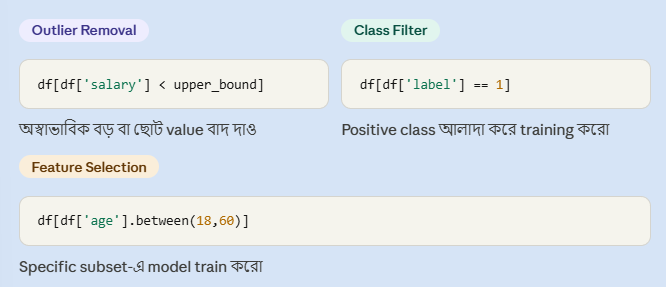